In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from scipy.stats import norm
import seaborn as sns

import sys
sys.path.append("src")

from data_generation import *
from neural_networks import *
from estimation import *
from train_varying_products import *

pd.options.mode.chained_assignment = None 
pd.set_option("display.precision", 4)

### Inference with debiasing term

In [2]:
def moment_func(x_1, x_2, model, delta):
    # apply price change 
    new_x_1 = x_1.clone()
    new_x_1[:,:,-1] = new_x_1[:,:,-1] * (1+delta)  ## in data generation, the last feature is price
    
    # calculate moment
    a1 = model(x_2, new_x_1)
    a0 = model(x_2, x_1)
    moment = a1 - a0
    
    return moment, a0
    

In [3]:
def alpha_loss(x_1, x_2, model, delta): 
    moment, alpha = moment_func(x_1, x_2, model, delta)
    return (alpha**2 - moment * 2).mean()


In [4]:
def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # if using multi-GPU setups
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


In [5]:
def train_alpha(data, delta):
    K = data['K']
    x_1, x_2 = x_transform_mm(data)
    model = SmallDeepSet(x_d = K+1)
    model = model.cuda()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    
    losses = []
    x_1, x_2 = torch.from_numpy(x_1).float().cuda(), torch.from_numpy(x_2).float().cuda()

    for _ in range(5000):
        loss = alpha_loss(x_1, x_2, model, delta)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        if loss < 1e-10:
            break
        #print(loss)
    return model, losses

In [6]:
def pred_theta(f_model, alpha_model, data, delta):
    x_1, x_2 = x_transform_mm(data) 
    y = data['Y']
    x_1, x_2, y = torch.from_numpy(x_1).float().cuda(), torch.from_numpy(x_2).float().cuda(), torch.from_numpy(y).float().cuda()
    
    ## the effect of price change on market share estimated using f_model 
    new_x_1 = x_1.clone()
    new_x_1[:,:,-1] = new_x_1[:,:,-1] * (1+delta)  ## in data generation, the last feature is price
    # calculate change in market share
    y1 = f_model(x_2, new_x_1)
    y0 = f_model(x_2, x_1)
    m_est = y1-y0
    ## alpha hat 
    alpha_hat = alpha_model(x_2, x_1) 
    theta = m_est + alpha_hat * (y-y0)
    
    return m_est, theta, alpha_hat, y0
    

In [7]:
def Inference(J, M, K, seed, dg, params,  delta = 0.01):
    
    setup = [J, K, M, str(dg).split()[1], seed]
    ### step 1: data generation 
    datax = data_generation(params, J, K, M, seed, dg)
    
    data_f1, data_f2 = split_train_test(datax, p = 0.5)
    
    ### step 2: estimation by each fold of data 
    ## estimation of fold 2
    ## train on the left out data
    f_model, loss_f = train_deep(data_f1)
    alpha_model, loss_alpha = train_alpha(data_f1, delta)
    ## apply the trained f and alpha to the fold
    m_est1, theta1, alpha_hat1, f_hat1 = pred_theta(f_model, alpha_model, data_f2, delta)
    
    ## estimation of fold 1
    ## train on the left out data
    f_model, loss_f = train_deep(data_f2)
    alpha_model, loss_alpha = train_alpha(data_f2, delta)
    ## apply the trained f and alpha to the fold
    m_est2, theta2, alpha_hat2, f_hat2 = pred_theta(f_model, alpha_model, data_f1, delta)
    
    ### step 3: report the estimation result
    theta = torch.cat((theta1, theta2), dim=0)
    theta_hat = theta.mean()
    theta_sd = theta.std()
    
    return theta_hat.cpu().detach().numpy(), theta_sd.cpu().detach().numpy()

In [8]:
def pred_theta_nc_cf(data, pred_method, seed, new_params, delta =0.01):
    large_record = pd.DataFrame()
    J = data['J']
    old_pred = pred_method(data, new_params)

    for prod_id in range(J):        
        X = data['X'].copy()
        M = data['M']

        ## update price
        record = pd.DataFrame({'old_price' : X['price'].copy()})

        for m in range(M):
            new_id = prod_id + m * J
            X['price'].iloc[new_id] = (1 + delta) * X['price'].iloc[new_id]

        new_data = data.copy()
        new_data['X'] = X

        ## pred y 
        new_pred = pred_method(new_data,new_params)

        record['new_pred_share'] = new_pred
        record['old_pred_share'] = old_pred

        record['pred_change'] = record['new_pred_share'] - record['old_pred_share']

        record['i'] = prod_id
        record['j'] = record.index % data['J']
        large_record = pd.concat([large_record, record]).reset_index(drop=True)

    return large_record.loc[large_record.i == large_record.j,'pred_change']


def Inference_plugin_cf(J, M, K, seed, dg, params,  delta = 0.01):
    
    setup = [J, K, M, str(dg).split()[1], seed]
    ### step 1: data generation 
    datax = data_generation(params, J, K, M, seed, dg)
    
    data_f1, data_f2 = split_train_test(datax, p = 0.5)
    
    ### step 2: estimation by each fold of data 
    ## estimation of fold 2
    ## train on the left out data
    set_seed(seed)
    f_model1, loss_f = train_deep(data_f1)
    # alpha_model, loss_alpha = train_alpha(data_f1, delta)
    ## apply the trained f and alpha to the fold
    theta_deep1 = pred_theta_nc_cf(data_f2, pred_deep, seed,  f_model1,  delta)
    
    ## estimation of fold 1
    ## train on the left out data
    set_seed(seed)
    f_model2, loss_f = train_deep(data_f2)
    # alpha_model, loss_alpha = train_alpha(data_f2, delta)
    ## apply the trained f and alpha to the fold
    theta_deep2 = pred_theta_nc_cf(data_f1, pred_deep, seed,  f_model2,  delta)
    
    ### step 3: report the estimation result
    theta = pd.concat((theta_deep1, theta_deep2))
    theta_hat = theta.mean()
    theta_sd = theta.std()
    
    return theta_hat, theta_sd

In [9]:
def true_theta(J, M, K, seed, dg, params,  delta = 0.01): 
    
    data = data_generation(params, J, K, M * 20, seed, dg)
    
    large_record = pd.DataFrame()

    for prod_id in range(J):
        record = cal_true_share_change(data, dg, prod_id, delta, seed)
        record['i'] = prod_id
        record['j'] = record.index % data['J']
        large_record = pd.concat([large_record, record]).reset_index(drop=True)

    true = large_record.loc[large_record.i == large_record.j,'true_change'].mean()
    
    return true

In [10]:
def PlugIn_theta(J, M, K, seed, dg, params, hyper_params,  delta = 0.01):
    
    setup = [J, K, M, str(dg).split()[1], seed]
    ### step 1: data generation 
    datax = data_generation(params, J, K, M, seed, dg)
    
    ### step 2: train
    m1_rcl, losses_rcl = train_rcl(datax)
    m1_mnl, losses_mnl = train_logit(datax)
    m1_deep, losses_deep = train_deep(datax)
    m1_single,losses_single = train_single(datax, hyper_params)
    
    ### step 3: plug-in
    theta_rcl = pred_theta_nc(datax, pred_rcl, seed,  m1_rcl,  delta = 0.01)
    theta_mnl = pred_theta_nc(datax, pred_logit2, seed,  m1_mnl,  delta = 0.01)
    theta_deep = pred_theta_nc(datax, pred_deep, seed,  m1_deep,  delta = 0.01)
    theta_single = pred_theta_nc(datax, pred_single, seed,  m1_single,  delta = 0.01)
    
    ## step 4: our method
    #theta_hat, theta_sd = Inference(datax,  delta = 0.01)
    
    return [theta_rcl, theta_mnl, theta_deep, theta_single] #[theta_hat, theta_sd],


def pred_theta_nc(data, pred_method, seed, new_params, delta =0.01):
    large_record = pd.DataFrame()
    J = data['J']
    old_pred = pred_method(data, new_params)

    for prod_id in range(J):        
        X = data['X'].copy()
        M = data['M']

        ## update price
        record = pd.DataFrame({'old_price' : X['price'].copy()})

        for m in range(M):
            new_id = prod_id + m * J
            X['price'].iloc[new_id] = (1 + delta) * X['price'].iloc[new_id]

        new_data = data.copy()
        new_data['X'] = X

        ## pred y 
        new_pred = pred_method(new_data,new_params)

        record['new_pred_share'] = new_pred
        record['old_pred_share'] = old_pred

        record['pred_change'] = record['new_pred_share'] - record['old_pred_share']

        record['i'] = prod_id
        record['j'] = record.index % data['J']
        large_record = pd.concat([large_record, record]).reset_index(drop=True)

    true = large_record.loc[large_record.i == large_record.j,'pred_change'].mean()
    true_sd = large_record.loc[large_record.i == large_record.j,'pred_change'].std()
    
    return [true, true_sd]

In [11]:
def cal_cover(true, theta_hat, theta_sd, J, M):
    ci_l = theta_hat - 1.96 * theta_sd / np.sqrt(J * M)
    ci_u = theta_hat + 1.96 * theta_sd / np.sqrt(J * M)
    cover = (ci_l < true) & (ci_u >  true)
    significant = ci_u < 0
    bias = np.abs(theta_hat - true)
    
    return np.mean(bias), np.mean(cover), np.mean(significant)

### results

In [12]:
np.random.seed(102666)
seed_list = np.random.choice(1000000, 100, replace=False)
seed_list

array([357409, 147442, 759978, 549771, 161756, 775466, 325401, 155680,
       399322, 582773, 356063, 130624, 882984, 916183, 784266, 447246,
       249366, 844921, 200302, 281658, 964930, 104203, 837427, 765775,
       412319, 563918, 783145, 620206, 246769, 468635, 147440, 398145,
       911726, 506965, 688369, 761019,  11693, 245782, 541848, 302682,
       922835, 794901, 333573, 650404,  32602, 128420, 358671, 530248,
       586726, 248392, 385817, 344729, 255930, 524650, 121945, 360292,
        61751, 912498, 305725,  18753, 575233, 481054, 430340, 857625,
        62724, 685801, 975127, 434134, 837012, 768948, 500797, 929812,
       347000, 653743, 969576, 130140, 877666, 797856, 723095, 721695,
       367248,  37581, 854434, 848326, 880946, 796192, 315609, 298983,
       753377,  57695, 226625, 271325, 152336, 890792, 703039,  97420,
       549461, 576667, 108212, 877857])

In [33]:
## RCL
J = 3
M = 100
K = 5
# set_seed(102666)
#params = [np.random.normal(0,1,K+2)/ (K * 2) , np.ones(K+2)] 
params = [np.ones(K+2) , np.ones(K+2) * 0.5] 
params[0][-1] = -1
dg = rcl 
delta = 0.01

#seed = 102666
#true = true_theta(J, M, K, seed, dg, params,  delta)
#print(true)

# RCL
rslt_rcl = []

for seed in seed_list[0:100]:
    set_seed(seed)
    true = true_theta(J, M, K, seed, dg, params,  delta)
    theta_hat, theta_sd = Inference(J, M, K, seed, dg, params,   delta = 0.01)
    ci_l = theta_hat - 1.96 * theta_sd / np.sqrt(J * M)
    ci_u = theta_hat + 1.96 * theta_sd / np.sqrt(J * M)
    cover = (ci_l < true) & (ci_u > true)
    significant = ci_u < 0
    bias = theta_hat - true
    ci_l90 = theta_hat - 1.64 * theta_sd / np.sqrt(J * M )
    ci_u90 = theta_hat + 1.64 * theta_sd / np.sqrt(J * M )
    cover90 = (ci_l90 < true) & (ci_u90 > true)
    print(seed, cover, significant, bias, cover90)
    rslt_rcl.append([seed, theta_hat, theta_sd, true, ci_l, ci_u, cover, significant, bias])

357409 True True 3.501472713341282e-05 True
147442 True True -7.740656852768405e-05 True
759978 True True -9.099794862968652e-05 True
549771 True True 0.00012120027878039863 True
161756 True True 8.056536006383367e-06 True
775466 False True -0.0002645606659632375 False
325401 True True 4.634935513953453e-05 True
155680 True True -1.4105039331219855e-05 True
399322 True True -1.8807482472923617e-07 True
582773 True True -1.6817372276468033e-05 True
356063 True True -4.563225072037793e-06 True
130624 True True -1.4110873267193054e-05 True
882984 True True -1.0706832517246414e-05 True
916183 True True -8.234947176121148e-06 True
784266 True True -6.262642819499387e-07 True
447246 True True -0.00010419279355628288 True
249366 True True -0.00012657302396014425 True
844921 True True 2.073552983794264e-05 True
200302 False True 0.00017564280955499872 False
281658 True True -9.18376174139225e-05 True
964930 True True 6.026462332332956e-05 True
104203 True True 4.1917281647767e-06 True
837427 T

In [34]:
rslt_rcl_df = pd.DataFrame(rslt_rcl, columns = ['seed', 'theta_hat', 'theta_sd', 'true', 'ci_l', 'ci_u', 'cover', 'significant', 'bias'])

In [35]:
rslt_rcl_df.to_csv('inference_rcl_0224.csv')

In [36]:
## Table 6 Row 1 
rslt_rcl_df.iloc[0:100,].mean()

seed           4.9894e+05
theta_hat     -1.3457e-03
theta_sd       1.4493e-03
true          -1.3328e-03
ci_l          -1.5097e-03
ci_u          -1.1817e-03
cover          9.1000e-01
significant    1.0000e+00
bias          -1.2898e-05
dtype: float64

In [17]:
## MNL
J = 3
M = 100
K = 5
set_seed(102666)
params = np.ones(K+2)
params[-1] = -1
dg = mnl
delta = 0.01
seed = 102666

mnl_true = true_theta(J, M, K, seed, dg, params,  delta)

In [18]:
mnl_true

-0.0015831575243673713

In [20]:
# MNL
rslt_mnl = []

for seed in seed_list[0:50]:
    set_seed(seed)
    theta_hat, theta_sd = Inference(J, M, K, seed, dg, params, delta = 0.01)
    ci_l = theta_hat - 1.96 * theta_sd / np.sqrt(J * M )
    ci_u = theta_hat + 1.96 * theta_sd / np.sqrt(J * M )
    cover = (ci_l < mnl_true) & (ci_u > mnl_true)
    significant = ci_u < 0
    bias = theta_hat - mnl_true
    print(seed, theta_hat, theta_sd, mnl_true, ci_l, ci_u, cover, significant, bias)
    rslt_mnl.append([seed, theta_hat, theta_sd, mnl_true, ci_l, ci_u, cover, significant, bias])

357409 -0.0015645737 0.0019608948 -0.0015831575243673713 -0.001786469864002624 -0.0013426775948189112 True True 1.8583794956603767e-05
147442 -0.0015431141 0.0020630385 -0.0015831575243673713 -0.0017765688645163952 -0.0013096592919459166 True True 4.004344613621545e-05
759978 -0.0016167827 0.002006117 -0.0015831575243673713 -0.001843796253308033 -0.0013897692299342404 True True -3.362521725376534e-05
549771 -0.0014009154 0.0017690848 -0.0015831575243673713 -0.001601106234622366 -0.001200724645721548 True True 0.0001822420841954143
161756 -0.0015685864 0.0019997084 -0.0015831575243673713 -0.0017948747522845124 -0.001342298145993128 True True 1.4571075228551151e-05
775466 -0.0017877434 0.0020396782 -0.0015831575243673713 -0.002018554726982708 -0.0015569321025216628 True True -0.00020458589038481402
325401 -0.001495258 0.0017362201 -0.0015831575243673713 -0.001691729749903448 -0.0012987861527349873 True True 8.789957304815364e-05
155680 -0.0015449228 0.0019301678 -0.0015831575243673713 -0

In [21]:
for seed in seed_list[50:100]:
    set_seed(seed)
    theta_hat, theta_sd = Inference(J, M, K, seed, dg, params, delta = 0.01)
    ci_l = theta_hat - 1.96 * theta_sd / np.sqrt(J * M )
    ci_u = theta_hat + 1.96 * theta_sd / np.sqrt(J * M )
    cover = (ci_l < mnl_true) & (ci_u > mnl_true)
    significant = ci_u < 0
    bias = theta_hat - mnl_true
    print(seed, theta_hat, theta_sd, mnl_true, ci_l, ci_u, cover, significant, bias)
    rslt_mnl.append([seed, theta_hat, theta_sd, mnl_true, ci_l, ci_u, cover, significant, bias])

385817 -0.0016295644 0.002214164 -0.0015831575243673713 -0.0018801206898697042 -0.001379008201061902 True True -4.6406921098431824e-05
344729 -0.0016889378 0.0020671245 -0.0015831575243673713 -0.0019228549274814032 -0.0014550206185120441 True True -0.00010578024862935233
255930 -0.0014424344 0.0017804723 -0.0015831575243673713 -0.001643913795587295 -0.0012409549696625534 True True 0.00014072314174244714
524650 -0.0016900097 0.0020685196 -0.0015831575243673713 -0.0019240847525923567 -0.0014559346979678555 True True -0.00010685220091273475
121945 -0.0014995389 0.0019208484 -0.0015831575243673713 -0.0017169033492047392 -0.00128217443469278 True True 8.361863241861177e-05
360292 -0.0017472812 0.002021818 -0.0015831575243673713 -0.001976071413854203 -0.0015184909344966796 True True -0.00016412364980806994
61751 -0.001550197 0.0020421774 -0.0015831575243673713 -0.0017812911430428917 -0.0013191028954406088 True True 3.296050512562108e-05
912498 -0.0015983278 0.0019195327 -0.001583157524367371

In [22]:
rslt_mnl_df = pd.DataFrame(rslt_mnl[0:100], columns = ['seed', 'theta_hat', 'theta_sd', 'true', 'ci_l', 'ci_u', 'cover', 'significant', 'bias'])
rslt_mnl_df['true'] = mnl_true

In [37]:
## Table 6 Row 2

rslt_mnl_df.mean().astype(float)

seed           4.9894e+05
theta_hat     -1.5582e-03
theta_sd       1.9271e-03
true          -1.5832e-03
ci_l          -1.7763e-03
ci_u          -1.3402e-03
cover          9.2000e-01
significant    1.0000e+00
bias           2.4915e-05
dtype: float64

In [28]:
rslt_mnl_df['cover']

0     True
1     True
2     True
3     True
4     True
      ... 
95    True
96    True
97    True
98    True
99    True
Name: cover, Length: 100, dtype: bool

In [38]:
rslt_mnl_df.to_csv('inference_mnl_0224.csv.csv')

### Visualization and Comparison

In [41]:
## RCL
J = 3
M = 100
K = 5
np.random.seed(102666)
params = [np.ones(K+2) , np.ones(K+2) * 0.5] 
params[0][-1] = -1
dg = rcl 
delta = 0.01
hyper_params = {'hidden_size': 256, 'num_hidden_layers': 5, 'n_epochs': 2000, 'learning_rate': 0.0001}


In [44]:
rslt_rcl = []

for seed in seed_list[0:100]:
    set_seed(seed)
    rslt = PlugIn_theta(J, M, K, seed, dg, params, hyper_params,  delta = 0.01)
    rslt_rcl.append([item for sublist in rslt for item in sublist])
    print(rslt)
    
rslt_rcl_inf_df2= pd.DataFrame(rslt_rcl)
rslt_rcl_inf_df2.to_csv('rslt_rcl_inf_df2_0224.csv')

[[-0.0013649897, 0.001345081], [-0.0014795869, 0.0015046143], [-0.001342273, 0.0014779326], [-0.0014374295, 0.0014991786]]
[[-0.0013024964, 0.001334033], [-0.0013887733, 0.0014481703], [-0.0012469869, 0.001380554], [-0.0013408645, 0.0014856872]]
[[-0.0014574192, 0.0013915312], [-0.0015517911, 0.0014923193], [-0.0014356901, 0.001548865], [-0.0013925749, 0.0014282746]]
[[-0.0012768235, 0.0013440555], [-0.0013600341, 0.001479254], [-0.0012631009, 0.0014781208], [-0.0012979257, 0.0014455836]]
[[-0.001326741, 0.0013495205], [-0.0014148109, 0.0014768518], [-0.0013284482, 0.0014531778], [-0.0013511477, 0.0014546522]]
[[-0.0013830215, 0.0013330792], [-0.0015251206, 0.0014460927], [-0.0013756747, 0.0014301853], [-0.0014188268, 0.0013706505]]
[[-0.0013301315, 0.0013154119], [-0.0014155955, 0.0014382899], [-0.0012183731, 0.0012893244], [-0.0014338096, 0.0015576876]]
[[-0.001321852, 0.0013324133], [-0.0014057277, 0.0014194694], [-0.0013466845, 0.0014150081], [-0.0014117539, 0.0015352438]]
[[-0.001

In [45]:
rslt_rcl_inf_df2.columns = [ 'rcl_hat', 'rcl_sd', 'mnl_hat', 'mnl_sd', 'our_nc_hat', 'our_nc_sd',
                            'single_hat', 'single_sd'] # 'our_c_hat', 'our_c_sd',

In [46]:
rslt_rcl_inf_df2

,rcl_hat,rcl_sd,mnl_hat,mnl_sd,our_nc_hat,our_nc_sd,single_hat,single_sd
0,-0.0014,0.0013,-0.0015,0.0015,-0.0013,0.0015,-0.0014,0.0015
1,-0.0013,0.0013,-0.0014,0.0014,-0.0012,0.0014,-0.0013,0.0015
2,-0.0015,0.0014,-0.0016,0.0015,-0.0014,0.0015,-0.0014,0.0014
3,-0.0013,0.0013,-0.0014,0.0015,-0.0013,0.0015,-0.0013,0.0014
4,-0.0013,0.0013,-0.0014,0.0015,-0.0013,0.0015,-0.0014,0.0015
...,...,...,...,...,...,...,...,...
95,-0.0013,0.0014,-0.0014,0.0015,-0.0013,0.0014,-0.0013,0.0014
96,-0.0012,0.0013,-0.0013,0.0014,-0.0012,0.0014,-0.0012,0.0014
97,-0.0013,0.0013,-0.0014,0.0015,-0.0013,0.0014,-0.0013,0.0014
98,-0.0013,0.0013,-0.0014,0.0015,-0.0013,0.0015,-0.0013,0.0014


In [48]:
rslt_rcl_inf_df2['true'] = true_theta(J, M, K, seed, dg, params,  delta)

In [53]:
rslt_rcl_df

,seed,theta_hat,theta_sd,true,ci_l,ci_u,cover,significant,bias
0,357409,-0.0013201509,0.001438736,-0.0014,-0.0015,-0.0012,True,True,3.5015e-05
1,147442,-0.0014270353,0.0016524045,-0.0013,-0.0016,-0.0012,True,True,-7.7407e-05
2,759978,-0.0014186775,0.0015348085,-0.0013,-0.0016,-0.0012,True,True,-9.0998e-05
3,549771,-0.0012215088,0.0013495242,-0.0013,-0.0014,-0.0011,True,True,1.2120e-04
4,161756,-0.0013062353,0.0014683885,-0.0013,-0.0015,-0.0011,True,True,8.0565e-06
...,...,...,...,...,...,...,...,...,...
95,97420,-0.001404029,0.0015701444,-0.0013,-0.0016,-0.0012,True,True,-8.1748e-05
96,549461,-0.0012729955,0.0013859825,-0.0014,-0.0014,-0.0011,True,True,8.7367e-05
97,576667,-0.0012852217,0.0014928711,-0.0013,-0.0015,-0.0011,True,True,5.8088e-05
98,108212,-0.001308389,0.0015033089,-0.0013,-0.0015,-0.0011,True,True,1.1741e-05


### Figure 3 

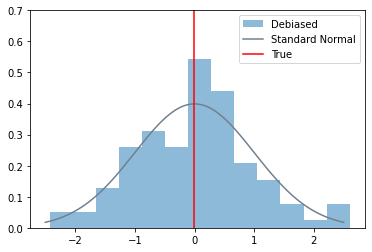

In [73]:
# Histogram for rslt_mnl_inf_df[0]
plt.hist((rslt_rcl_df['theta_hat'] - rslt_rcl_df['theta_hat'].mean())/rslt_rcl_df['theta_hat'].std(), 
         bins=13, alpha=0.5, label='Debiased', density=True)

## add std normal
x = np.linspace(-2.5, 2.5, 100)  # Range for x-axis
y = norm.pdf(x, 0, 1)  # PDF of the standard normal distribution
plt.plot(x, y, label='Standard Normal',color = 'slategray')


plt.axvline(rslt_rcl_inf_df2['true'][0],  linestyle='-', label='True', color = 'red')

# Show the plot with a legend
plt.legend(loc='upper right')
plt.ylim(0, 0.7)

plt.savefig('inf_corrected_v2.png')
plt.show()

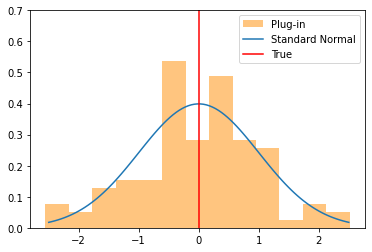

In [74]:
# Histogram for rslt_mnl_inf_df[0]
plt.hist((rslt_rcl_inf_df2['our_nc_hat'] -rslt_rcl_inf_df2['our_nc_hat'].mean())/rslt_rcl_inf_df2['our_nc_hat'].std(), 
         bins=13, alpha=0.5, label='Plug-in', density = True, color = 'darkorange') 
## add std normal
x = np.linspace(-2.5, 2.5, 100)  # Range for x-axis
y = norm.pdf(x, 0, 1)  # PDF of the standard normal distribution
plt.plot(x, y,  label='Standard Normal')

plt.axvline(rslt_rcl_inf_df2['true'][0], color='red', linestyle='-', label='True')

# Show the plot with a legend
plt.legend(loc='upper right')
plt.ylim(0, 0.7)

plt.savefig('inf_deep_v2.png')
plt.show()